# Experiment 5.3.2.3 — FF-SNN before RSNN64

Analysis-only notebook for the finalized pre-recurrent transformation ablation.

Sections: Reference contract, Primary architecture comparison, Paired deltas vs direct, Spiking-transform attribution, FF-width sensitivity, Generalization, History contribution, SNN-native accessibility, Efficiency/state dimension, and decision table.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "AGENTS.md").exists() and (candidate / "scripts").exists():
            return candidate
    raise FileNotFoundError("Could not locate writingRing repository root")


repo_root = find_repo_root()
artifact_root = repo_root / "notebooks" / "artifacts" / "experiment_5_3_2_3_ff_before_rsnn" / "ff_before_rsnn_v1"
manifest = json.loads((artifact_root / "manifest.json").read_text(encoding="utf-8"))
runs = pd.read_csv(artifact_root / "runs.csv")
histories = pd.read_csv(artifact_root / "histories.csv")
probe_runs = pd.read_csv(artifact_root / "probe_runs.csv")
ablation_runs = pd.read_csv(artifact_root / "ablation_runs.csv")
history_gain_runs = pd.read_csv(artifact_root / "history_gain_runs.csv")
activity_runs = pd.read_csv(artifact_root / "activity_runs.csv")
representation_runs = pd.read_csv(artifact_root / "representation_runs.csv")
baseline_runs = pd.read_csv(artifact_root / "baseline_runs.csv")
local_reference = pd.read_csv(artifact_root / "local_reference.csv")
paired_deltas = pd.read_csv(artifact_root / "paired_deltas.csv")

assert manifest["expected_train_runs"] == 15
assert manifest["expected_comparison_rows"] == 20
assert len(runs) == 20
assert runs.groupby("condition")["seed"].nunique().eq(5).all()
manifest


{'aggregation_policy': 'finalizer requires 15 new train/evaluate runs, 5 direct references, and five baseline artifacts; it only aggregates existing artifacts',
 'architecture_contract': {'direct_rsnn64': 'WHAT128 -> RSNN64',
  'ffsnn128_rsnn64': 'WHAT128 -> short-tau FF-SNN128 spikes -> RSNN64',
  'ffsnn64_rsnn64': 'WHAT128 -> short-tau FF-SNN64 spikes -> RSNN64',
  'linear64_rsnn64': 'WHAT128 -> Linear64 -> RSNN64'},
 'causality_contract': 'T_i is used only to construct phase/progress supervision and valid masks; no model condition receives final duration',
 'checkpoint_selection': 'min validation joint objective loss; tie lower progress MAE; tie higher phase BA',
 'conditions': ['direct_rsnn64',
  'linear64_rsnn64',
  'ffsnn64_rsnn64',
  'ffsnn128_rsnn64'],
 'direct_reuse': 'Exp5.3.2.2 rsnn_h64 checkpoints/evaluations/histories are reused by identity-validated references and are never retrained',
 'expected_comparison_rows': 20,
 'expected_train_runs': 15,
 'experiment_id': 'experim

## 1. Reference contract

The direct condition is reused Exp5.3.2.2 `rsnn_h64`. The three new conditions keep RSNN width fixed at H=64. `linear64_rsnn64` is the parameterization/depth control for `ffsnn64_rsnn64`.


In [2]:
condition_order = [
    "direct_rsnn64",
    "linear64_rsnn64",
    "ffsnn64_rsnn64",
    "ffsnn128_rsnn64",
]
summary = runs.groupby("condition", as_index=False).agg(
    phase_ba_mean=("probe_u_test_phase_ba", "mean"),
    phase_ba_sd=("probe_u_test_phase_ba", "std"),
    progress_mae_mean=("probe_test_sample_balanced_mae_mean", "mean"),
    progress_mae_sd=("probe_test_sample_balanced_mae_mean", "std"),
    spearman_mean=("probe_test_spearman_mean", "mean"),
    violation_mean=("probe_test_monotonic_violation_rate_mean", "mean"),
    parameter_count=("parameter_count", "mean"),
)
summary["condition"] = pd.Categorical(summary["condition"], categories=condition_order, ordered=True)
summary = summary.sort_values("condition").reset_index(drop=True)
summary


,condition,phase_ba_mean,phase_ba_sd,progress_mae_mean,progress_mae_sd,spearman_mean,violation_mean,parameter_count
0,direct_rsnn64,0.355236,0.010501,0.126337,0.005163,0.931670,0.296387,13003.0
1,linear64_rsnn64,0.358750,0.004184,0.127391,0.002006,0.938611,0.298507,17099.0
2,ffsnn64_rsnn64,0.349340,0.008091,0.125954,0.004282,0.932414,0.276400,17099.0
3,ffsnn128_rsnn64,0.354430,0.009879,0.123529,0.004502,0.934120,0.278494,29387.0


## 2. Primary architecture comparison

The primary scientific test is whether `ffsnn64_rsnn64` improves the final RSNN membrane representation relative to `direct_rsnn64`.


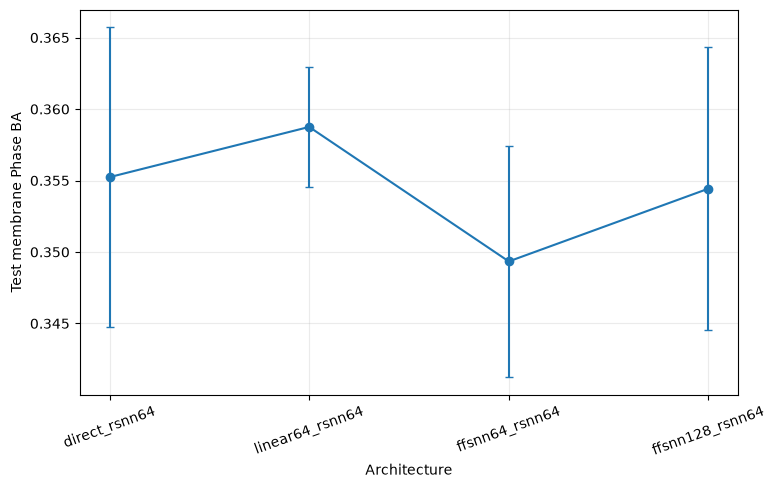

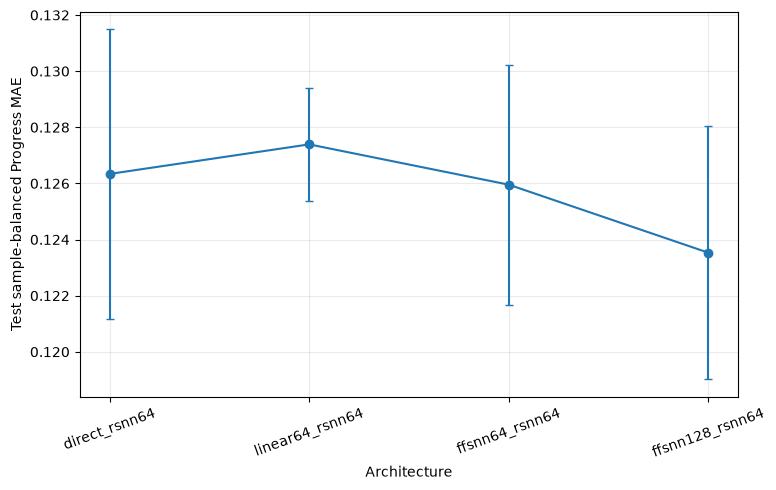

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.errorbar(summary["condition"].astype(str), summary["phase_ba_mean"], yerr=summary["phase_ba_sd"], marker="o", capsize=3)
ax.set_ylabel("Test membrane Phase BA")
ax.set_xlabel("Architecture")
ax.tick_params(axis="x", rotation=20)
ax.grid(alpha=0.25)
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.errorbar(summary["condition"].astype(str), summary["progress_mae_mean"], yerr=summary["progress_mae_sd"], marker="o", capsize=3)
ax.set_ylabel("Test sample-balanced Progress MAE")
ax.set_xlabel("Architecture")
ax.tick_params(axis="x", rotation=20)
ax.grid(alpha=0.25)
plt.show()


## 3. Paired deltas vs direct RSNN64

Positive `delta_phase_ba` is better. Negative `delta_progress_mae` and negative `delta_violation` are better. The table also reports per-seed win counts to distinguish a stable gain from a mean driven by one seed.


In [4]:
paired_summary = paired_deltas.groupby("condition", as_index=False).agg(
    mean_delta_phase_ba=("delta_phase_ba", "mean"),
    sd_delta_phase_ba=("delta_phase_ba", "std"),
    mean_delta_progress_mae=("delta_progress_mae", "mean"),
    sd_delta_progress_mae=("delta_progress_mae", "std"),
    mean_delta_spearman=("delta_spearman", "mean"),
    mean_delta_violation=("delta_violation", "mean"),
)
win_counts = paired_deltas.groupby("condition").agg(
    phase_wins=("delta_phase_ba", lambda s: int((s > 0).sum())),
    progress_wins=("delta_progress_mae", lambda s: int((s < 0).sum())),
    joint_wins=("seed", lambda s: 0),
).reset_index()
for idx, row in win_counts.iterrows():
    condition = row["condition"]
    subset = paired_deltas[paired_deltas["condition"] == condition]
    win_counts.loc[idx, "joint_wins"] = int(((subset["delta_phase_ba"] > 0) & (subset["delta_progress_mae"] < 0)).sum())
paired_summary.merge(win_counts, on="condition")


,condition,mean_delta_phase_ba,sd_delta_phase_ba,mean_delta_progress_mae,sd_delta_progress_mae,mean_delta_spearman,mean_delta_violation,phase_wins,progress_wins,joint_wins
0,ffsnn128_rsnn64,-0.000806,0.002507,-0.002807,0.002414,0.002451,-0.017893,2,4,2
1,ffsnn64_rsnn64,-0.005897,0.008840,-0.000383,0.004278,0.000744,-0.019987,2,3,2
2,linear64_rsnn64,0.003513,0.010439,0.001054,0.003720,0.006942,0.002120,3,1,1


## 4. Spiking-transform attribution

`linear64_rsnn64` and `ffsnn64_rsnn64` have matched weight shapes and paired initialization. Their difference isolates the short-tau LIF/spike transform much more cleanly than comparing either one only against the direct network.


In [5]:
pair = runs[runs["condition"].isin(["linear64_rsnn64", "ffsnn64_rsnn64"])].pivot(index="seed", columns="condition")
mechanism = pd.DataFrame({
    "seed": pair.index,
    "delta_phase_ba_ff_minus_linear": pair["probe_u_test_phase_ba"]["ffsnn64_rsnn64"] - pair["probe_u_test_phase_ba"]["linear64_rsnn64"],
    "delta_progress_mae_ff_minus_linear": pair["probe_test_sample_balanced_mae_mean"]["ffsnn64_rsnn64"] - pair["probe_test_sample_balanced_mae_mean"]["linear64_rsnn64"],
    "delta_spearman_ff_minus_linear": pair["probe_test_spearman_mean"]["ffsnn64_rsnn64"] - pair["probe_test_spearman_mean"]["linear64_rsnn64"],
})
mechanism


,seed,delta_phase_ba_ff_minus_linear,delta_progress_mae_ff_minus_linear,delta_spearman_ff_minus_linear
seed,,,,
11,11,-0.012588,0.000318,-0.019560
23,23,-0.021497,-0.000584,-0.018032
37,37,-0.008314,-0.004931,0.007417
53,53,-0.009984,0.001234,-0.005760
71,71,0.005331,-0.003220,0.004948


## 5. FF-width sensitivity

Compare `ffsnn128_rsnn64` with `ffsnn64_rsnn64`. The recurrent state is fixed, so a consistent gain from FF128 indicates that the front-end transformation width, not recurrent width, remains capacity-limited.


In [6]:
ff_pair = runs[runs["condition"].isin(["ffsnn64_rsnn64", "ffsnn128_rsnn64"])].pivot(index="seed", columns="condition")
ff_width_delta = pd.DataFrame({
    "seed": ff_pair.index,
    "delta_phase_ba_128_minus_64": ff_pair["probe_u_test_phase_ba"]["ffsnn128_rsnn64"] - ff_pair["probe_u_test_phase_ba"]["ffsnn64_rsnn64"],
    "delta_progress_mae_128_minus_64": ff_pair["probe_test_sample_balanced_mae_mean"]["ffsnn128_rsnn64"] - ff_pair["probe_test_sample_balanced_mae_mean"]["ffsnn64_rsnn64"],
})
ff_width_delta


,seed,delta_phase_ba_128_minus_64,delta_progress_mae_128_minus_64
seed,,,
11,11,-0.004092,0.000474
23,23,0.008304,-0.005798
37,37,0.007702,0.000480
53,53,0.012602,-0.003902
71,71,0.000937,-0.003377


## 6. Generalization

A transformed model should not be called better merely because its train representation improves. Compare train/validation/test probe performance and the existing train-val gaps.


In [7]:
generalization = runs.groupby("condition", as_index=False).agg(
    train_phase=("probe_u_train_phase_ba", "mean"),
    val_phase=("probe_u_val_phase_ba", "mean"),
    test_phase=("probe_u_test_phase_ba", "mean"),
    train_mae=("probe_train_sample_balanced_mae_mean", "mean"),
    val_mae=("probe_val_sample_balanced_mae_mean", "mean"),
    test_mae=("probe_test_sample_balanced_mae_mean", "mean"),
    phase_gap=("probe_phase_train_val_gap", "mean"),
    progress_gap=("probe_progress_val_train_gap", "mean"),
)
generalization


,condition,train_phase,val_phase,test_phase,train_mae,val_mae,test_mae,phase_gap,progress_gap
0,direct_rsnn64,0.471255,0.345050,0.355236,0.107984,0.130289,0.126337,0.126205,0.022305
1,ffsnn128_rsnn64,0.505136,0.343751,0.354430,0.103746,0.129877,0.123529,0.161386,0.026131
2,ffsnn64_rsnn64,0.485678,0.346905,0.349340,0.102338,0.127533,0.125954,0.138773,0.025195
3,linear64_rsnn64,0.470215,0.355257,0.358750,0.105075,0.126791,0.127391,0.114958,0.021717


## 7. History contribution

`H_reset` measures performance lost when temporal state is reset every timestep. `H_shuffle` measures performance lost when within-gesture temporal order is destroyed. For FF-SNN conditions, state reset removes both FF and recurrent state.


In [8]:
history_summary = history_gain_runs.groupby("condition", as_index=False).agg(
    H_reset_phase=("H_reset_phase_ba", "mean"),
    H_shuffle_phase=("H_shuffle_phase_ba", "mean"),
    H_reset_progress=("H_reset_progress_mae", "mean"),
    H_shuffle_progress=("H_shuffle_progress_mae", "mean"),
    H_reset_spearman=("H_reset_spearman", "mean"),
    H_shuffle_spearman=("H_shuffle_spearman", "mean"),
)
history_summary


,condition,H_reset_phase,H_shuffle_phase,H_reset_progress,H_shuffle_progress,H_reset_spearman,H_shuffle_spearman
0,direct_rsnn64,0.047235,0.112571,0.025927,0.059235,0.086356,0.287093
1,ffsnn128_rsnn64,0.061350,0.144390,0.040307,0.082495,0.117635,0.435526
2,ffsnn64_rsnn64,0.068992,0.120138,0.042586,0.071385,0.144375,0.355536
3,linear64_rsnn64,0.060135,0.106901,0.057521,0.048659,0.237325,0.232565


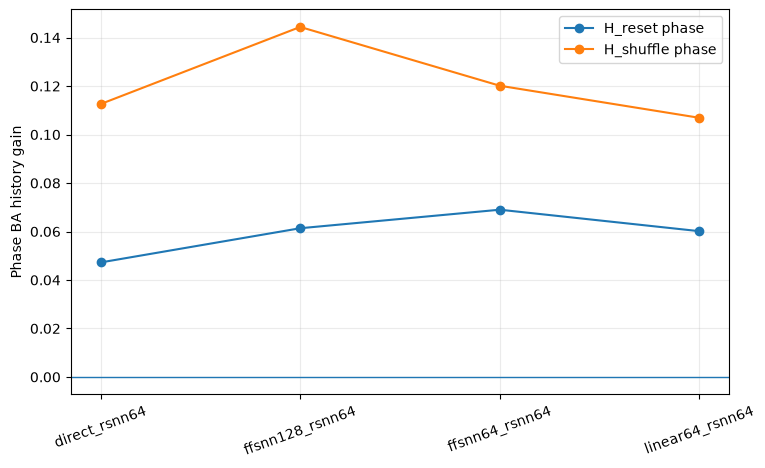

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.plot(history_summary["condition"], history_summary["H_reset_phase"], marker="o", label="H_reset phase")
ax.plot(history_summary["condition"], history_summary["H_shuffle_phase"], marker="o", label="H_shuffle phase")
ax.axhline(0.0, linewidth=1)
ax.set_ylabel("Phase BA history gain")
ax.tick_params(axis="x", rotation=20)
ax.legend()
ax.grid(alpha=0.25)
plt.show()


## 8. SNN-native accessibility

Compare membrane, synaptic, instantaneous spike, trailing-250ms count, and trailing-500ms count. A useful FF stage should ideally not improve membrane WHEN while making the information much harder to access from spikes.


In [10]:
accessibility = probe_runs.groupby(["condition", "feature_type"], as_index=False).agg(
    phase_ba=("phase_probe_test_ba", "mean"),
    progress_mae=("progress_probe_test_sample_balanced_mae_mean", "mean"),
)
accessibility


,condition,feature_type,phase_ba,progress_mae
0,direct_rsnn64,membrane,0.355236,0.126337
1,direct_rsnn64,spike,0.333421,0.127998
2,direct_rsnn64,spike250,0.324412,0.126326
3,direct_rsnn64,spike500,0.315913,0.126818
4,direct_rsnn64,synaptic,0.354523,0.126770
5,ffsnn128_rsnn64,membrane,0.354430,0.123529
6,ffsnn128_rsnn64,spike,0.342213,0.125300
7,ffsnn128_rsnn64,spike250,0.326825,0.125014
8,ffsnn128_rsnn64,spike500,0.313976,0.127639
9,ffsnn128_rsnn64,synaptic,0.356266,0.124166


## 9. Efficiency and effective state dimension

All conditions end in RSNN64, so compare parameter count, recurrent firing utilization, `effective_dimension`, and `pca90_dimension`.


In [11]:
activity_summary = activity_runs.groupby("condition", as_index=False).agg(
    mean_fr=("mean_firing_rate", "mean"),
    median_neuron_fr=("median_neuron_firing_rate", "mean"),
    dead_fraction=("dead_neuron_fraction", "mean"),
    highly_active_fraction=("highly_active_neuron_fraction", "mean"),
)
dimension_summary = representation_runs.groupby("condition", as_index=False).agg(
    effective_dimension=("effective_dimension", "mean"),
    pca90_dimension=("pca90_dimension", "mean"),
    total_variance=("total_variance", "mean"),
)
efficiency = summary[["condition", "parameter_count"]].merge(activity_summary, on="condition").merge(dimension_summary, on="condition")
efficiency


,condition,parameter_count,mean_fr,median_neuron_fr,dead_fraction,highly_active_fraction,effective_dimension,pca90_dimension,total_variance
0,direct_rsnn64,13003.0,0.350433,0.336150,0.000000,0.800000,4.239438,15.4,107.387183
1,linear64_rsnn64,17099.0,0.310629,0.255600,0.000000,0.821875,3.323711,10.2,102.200495
2,ffsnn64_rsnn64,17099.0,0.293975,0.249304,0.003125,0.737500,3.300782,12.6,105.512910
3,ffsnn128_rsnn64,29387.0,0.295940,0.250373,0.003125,0.756250,3.190365,13.0,115.942635


## 10. Decision table

There is no scalar composite score. First identify strict mean Pareto improvements over direct RSNN64: higher Phase BA and lower Progress MAE. Then inspect paired consistency, history gains, generalization, spike accessibility, and cost.


In [12]:
direct_row = summary[summary["condition"].astype(str) == "direct_rsnn64"].iloc[0]
decision = summary.copy()
decision["beats_direct_phase"] = decision["phase_ba_mean"] > direct_row["phase_ba_mean"]
decision["beats_direct_progress"] = decision["progress_mae_mean"] < direct_row["progress_mae_mean"]
decision["strict_pareto_vs_direct"] = decision["beats_direct_phase"] & decision["beats_direct_progress"]
decision.merge(history_summary, on="condition", how="left").merge(activity_summary, on="condition", how="left").merge(dimension_summary, on="condition", how="left")


,condition,phase_ba_mean,phase_ba_sd,progress_mae_mean,progress_mae_sd,spearman_mean,violation_mean,parameter_count,beats_direct_phase,beats_direct_progress,...,H_shuffle_progress,H_reset_spearman,H_shuffle_spearman,mean_fr,median_neuron_fr,dead_fraction,highly_active_fraction,effective_dimension,pca90_dimension,total_variance
0,direct_rsnn64,0.355236,0.010501,0.126337,0.005163,0.931670,0.296387,13003.0,False,False,...,0.059235,0.086356,0.287093,0.350433,0.336150,0.000000,0.800000,4.239438,15.4,107.387183
1,linear64_rsnn64,0.358750,0.004184,0.127391,0.002006,0.938611,0.298507,17099.0,True,False,...,0.048659,0.237325,0.232565,0.310629,0.255600,0.000000,0.821875,3.323711,10.2,102.200495
2,ffsnn64_rsnn64,0.349340,0.008091,0.125954,0.004282,0.932414,0.276400,17099.0,False,True,...,0.071385,0.144375,0.355536,0.293975,0.249304,0.003125,0.737500,3.300782,12.6,105.512910
3,ffsnn128_rsnn64,0.354430,0.009879,0.123529,0.004502,0.934120,0.278494,29387.0,False,True,...,0.082495,0.117635,0.435526,0.295940,0.250373,0.003125,0.756250,3.190365,13.0,115.942635
